# Verification of a terrain-following single-column firn model

This notebook verifies the vertical mass–thickness–compaction subsystem before any
horizontal transport or temperature physics is added.

The computational coordinate is $\zeta\in[0,1]$, increasing upward, and

$$
p=h\omega=h\frac{D\zeta}{Dt}
$$

has units of length per time. The equations used here are

$$
\partial_t(h\rho)+\partial_\zeta(\rho p)=0,
$$

$$
\partial_t h=a_s-a_b-h\int_0^1\frac{C}{\rho}\,d\zeta,
$$

$$
\partial_t h+\partial_\zeta p+h\frac{C}{\rho}=0,
$$

with $p(1)=-a_s$. The basal relation $p(0)=-a_b$ is not imposed separately;
it must emerge from compatibility.

For $C=c\,a_s(\rho_i-\rho)$, the steady solution is

$$
\rho(\zeta)=
\frac{\rho_s\rho_i}{
\rho_s+(\rho_i-\rho_s)e^{-\lambda(1-\zeta)}
},
\qquad
\lambda=\frac{ch\rho_i}{\rho_s},
$$

$$
p(\zeta)=-\frac{\rho_s a_s}{\rho(\zeta)}.
$$

In [1]:
from firedrake import *
from irksome import BackwardEuler, Dt, MeshConstant, TimeStepper

import math
import numpy as np
import matplotlib.pyplot as plt

## 0. Parameters and exact steady solution

The basal conversion rate is chosen so that a target basal density
$\rho_b=830\ {\rm kg\,m^{-3}}$ satisfies steady mass-flux compatibility,
$\rho_s a_s=\rho_b a_b$. This is only a verification closure.

In [2]:
rho_i_value = 917.0          # kg m^-3
rho_s_value = 300.0          # kg m^-3
rho_b_target_value = 830.0   # kg m^-3

a_s_value = 0.30             # m yr^-1

T_value = 243.15             # K
R_value = 8.314              # J mol^-1 K^-1

# Constant-c Herron--Langway coefficient at -30 C.
c_value = 11.0 * math.exp(-10160.0 / (R_value * T_value))

lambda_target_value = math.log(
    rho_b_target_value * (rho_i_value - rho_s_value)
    / (rho_s_value * (rho_i_value - rho_b_target_value))
)

# lambda = c h rho_i / rho_s.
h_target_value = (
    lambda_target_value * rho_s_value / (c_value * rho_i_value)
)

# Steady compatibility: rho_s a_s = rho_b a_b.
a_b_target_value = (
    rho_s_value * a_s_value / rho_b_target_value
)

print(f"c             = {c_value:.8f} m^-1")
print(f"lambda target = {lambda_target_value:.8f}")
print(f"h target      = {h_target_value:.8f} m")
print(f"a_b target    = {a_b_target_value:.8f} m yr^-1")

c             = 0.07222612 m^-1
lambda target = 2.97660413
h target      = 13.48275644 m
a_b target    = 0.10843373 m yr^-1


In [3]:
def rho_hl_numpy(zeta, h=h_target_value):
    """Constant-c steady density profile."""
    lam = c_value * h * rho_i_value / rho_s_value
    zeta = np.asarray(zeta)
    return (
        rho_i_value * rho_s_value
        / (
            rho_s_value
            + (rho_i_value - rho_s_value)
            * np.exp(-lam * (1.0 - zeta))
        )
    )


def p_hl_numpy(zeta, h=h_target_value):
    """Steady p from rho*p = -rho_s*a_s."""
    return -rho_s_value * a_s_value / rho_hl_numpy(zeta, h=h)


def rho_hl_ufl(zeta, h):
    """UFL version of the corrected steady density profile."""
    lam = c_value * h * rho_i_value / rho_s_value
    return (
        rho_i_value * rho_s_value
        / (
            rho_s_value
            + (rho_i_value - rho_s_value)
            * exp(-lam * (1.0 - zeta))
        )
    )


def sample_1d(f, points):
    """Sample a 1D function away from DG interfaces."""
    return np.array([float(f.at((float(x),))) for x in points])


def sample_extruded_column(f, zeta_points, x=0.5):
    """Sample the single extruded column at fixed horizontal coordinate."""
    return np.array([
        float(f.at((float(x), float(z)))) for z in zeta_points
    ])

## 1. Diagnostic $p$-solve on a literal 1D mesh

Solve

$$
p_\zeta+hg=0,\qquad p(1)=-a_s
$$

with constant $g=C/\rho$. The exact solution
$p=-a_s+hg(1-\zeta)$ lies exactly in $CG_1$.

In [4]:
n_vertical_test = 40

mesh_1d = UnitIntervalMesh(n_vertical_test)
zeta_1d = SpatialCoordinate(mesh_1d)[0]

V_p_1d = FunctionSpace(mesh_1d, "CG", 1)

# The equation is linear, so use a TrialFunction rather than wrapping it
# unnecessarily as a nonlinear residual.
p_trial = TrialFunction(V_p_1d)
psi_1d = TestFunction(V_p_1d)

p_1d = Function(V_p_1d, name="p")

h_given = Constant(h_target_value)
g_given = Constant(0.002)  # yr^-1

# p_zeta + h*g = 0
a_p_1d = p_trial.dx(0) * psi_1d * dx
L_p_1d = -h_given * g_given * psi_1d * dx

# UnitIntervalMesh:
# boundary 1 = zeta=0
# boundary 2 = zeta=1
bc_p_1d = DirichletBC(V_p_1d, -a_s_value, 2)

print("Top boundary dofs:", len(bc_p_1d.nodes))
assert len(bc_p_1d.nodes) == 1

solve(
    a_p_1d == L_p_1d,
    p_1d,
    bcs=bc_p_1d,
    solver_parameters={
        "ksp_type": "gmres",
        "ksp_rtol": 1.0e-12,
        "ksp_atol": 1.0e-14,
        "ksp_max_it": 200,
        "ksp_gmres_restart": 100,
        "pc_type": "none",
        "ksp_converged_reason": None,
    },
)

p_exact_1d = (
    -a_s_value
    + h_target_value * 0.002 * (1.0 - zeta_1d)
)

p_error_1d = sqrt(
    assemble((p_1d - p_exact_1d)**2 * dx)
)

print(f"1D diagnostic p error = {p_error_1d:.3e}")

assert p_error_1d < 1.0e-10

Top boundary dofs: 1
    Linear firedrake_0_ solve converged due to CONVERGED_ATOL iterations 40
1D diagnostic p error = 4.720e-16


## 2. Diagnostic \(p\)-solve on the intended extruded space

Repeat the same test with horizontal \(DG_0\), vertical \(CG_1\), one horizontal
cell, and many vertical layers. This isolates the tensor-product space and the
`"top"` boundary marker.

In [5]:
base_mesh_p = UnitIntervalMesh(1)
mesh_p = ExtrudedMesh(
    base_mesh_p,
    layers=n_vertical_test,
    layer_height=1.0 / n_vertical_test,
)

zeta_axis_p = mesh_p.geometric_dimension - 1
zeta_p = SpatialCoordinate(mesh_p)[zeta_axis_p]

V_p_ext = FunctionSpace(
    mesh_p,
    "DG", 0,
    vfamily="CG", vdegree=1,
)

p_ext = Function(V_p_ext, name="p")
psi_ext = TestFunction(V_p_ext)

F_p_ext = (
    p_ext.dx(zeta_axis_p) + h_given * g_given
) * psi_ext * dx

bc_p_ext = DirichletBC(V_p_ext, -a_s_value, "top")

p_exact_ext = (
    -a_s_value
    + h_target_value * float(g_given) * (1.0 - zeta_p)
)

p_ext.interpolate(p_exact_ext)

solve(
    F_p_ext == 0,
    p_ext,
    bcs=bc_p_ext,
    solver_parameters={
        "ksp_type": "gmres",
        "ksp_rtol": 1.0e-12,
        "ksp_atol": 1.0e-14,
        "ksp_max_it": 200,
        "ksp_gmres_restart": 100,
        "pc_type": "none",
        "ksp_converged_reason": None,
    },
)

p_error_ext = sqrt(assemble((p_ext - p_exact_ext)**2 * dx))

print(f"Extruded diagnostic p error = {p_error_ext:.3e}")
print(f"Constrained top dofs        = {len(bc_p_ext.nodes)}")

assert len(bc_p_ext.nodes) > 0
assert p_error_ext < 1.0e-11

    Linear firedrake_1_ solve converged due to CONVERGED_ATOL iterations 0
Extruded diagnostic p error = 3.126e-17
Constrained top dofs        = 1


## 3. Transport-only DG test

Prescribe constant negative $p$, fixed $h$, and $C=0$:

$$
\partial_t(h\rho)+\partial_\zeta(\rho p)=0.
$$

The upper boundary uses $\rho_s$ on inflow. The basal flux uses the interior
density. Both exterior mass fluxes are built from the actual $p$.

In [6]:
def run_transport_only(
    *,
    n_cells=80,
    dt_value=0.25,
    final_time=20.0,
    h_value=h_target_value,
    p_value=-0.20,
    rho_surface=rho_s_value,
    density_contrast=300.0,
):
    """
    Backward-Euler DG0 transport test on zeta in [0, 1].

    Initial profile:
        rho_0 = rho_surface + density_contrast*(1-zeta).
    """
    mesh = UnitIntervalMesh(n_cells)
    zeta = SpatialCoordinate(mesh)[0]

    V = FunctionSpace(mesh, "DG", 0)
    rho = Function(V, name="rho")
    rho_old = Function(V, name="rho_old")
    phi = TestFunction(V)

    h = Constant(h_value)
    p = Constant(p_value)
    rho_in = Constant(rho_surface)
    dt = Constant(dt_value)

    rho_initial_expr = rho_in + density_contrast * (1.0 - zeta)
    rho.interpolate(rho_initial_expr)
    rho_old.assign(rho)

    normal = FacetNormal(mesh)
    P = as_vector((p,))
    P_dot_n = dot(P, normal)
    outward_speed = 0.5 * (P_dot_n + abs(P_dot_n))

    # Numerical flux dotted with the '+' normal.
    flux_hat_nplus = (
        outward_speed("+") * rho("+")
        - outward_speed("-") * rho("-")
    )

    # At the top, p<0 is inflow.
    rho_top_upwind = conditional(p < 0.0, rho_in, rho)

    F = (
        h * (rho - rho_old) / dt * phi * dx

        # Zero for DG0 tests, but retained to show the complete weak form.
        - rho * p * phi.dx(0) * dx

        + (phi("+") - phi("-")) * flux_hat_nplus * dS

        # Top outward flux: n=+1.
        + rho_top_upwind * p * phi * ds(2)

        # Basal outward flux: n=-1.
        - rho * p * phi * ds(1)
    )

    problem = NonlinearVariationalProblem(F, rho)
    solver = NonlinearVariationalSolver(
        problem,
        solver_parameters={
        "ksp_type": "gmres",
        "ksp_rtol": 1.0e-12,
        "ksp_atol": 1.0e-14,
        "ksp_max_it": 200,
        "ksp_gmres_restart": 100,
    },
    )

    times = [0.0]
    masses = [assemble(h * rho * dx)]
    budget_errors = []

    time_value = 0.0

    while time_value < final_time - 1.0e-12:
        step_dt = min(dt_value, final_time - time_value)
        dt.assign(step_dt)

        M_old = assemble(h * rho_old * dx)

        solver.solve()

        M_new = assemble(h * rho * dx)

        top_outward = assemble(rho_in * p * ds(2, domain=mesh))
        basal_outward = assemble(-rho * p * ds(1, domain=mesh))

        numerical_Mdot = (M_new - M_old) / step_dt
        expected_Mdot = -(top_outward + basal_outward)

        budget_errors.append(numerical_Mdot - expected_Mdot)

        time_value += step_dt
        times.append(time_value)
        masses.append(M_new)

        rho_old.assign(rho)

    # Exact characteristic solution for the chosen linear initial profile.
    departure_point = zeta - p * final_time / h

    rho_exact_expr = conditional(
        departure_point <= 1.0,
        rho_in + density_contrast * (1.0 - departure_point),
        rho_in,
    )

    relative_L2_error = sqrt(
        assemble(
            (rho - rho_exact_expr)**2
            * dx(domain=mesh)
        )
        / assemble(
            rho_exact_expr**2
            * dx(domain=mesh)
        )
    )

    return {
        "mesh": mesh,
        "rho": rho,
        "rho_exact_expr": rho_exact_expr,
        "relative_L2_error": float(relative_L2_error),
        "times": np.asarray(times),
        "masses": np.asarray(masses),
        "budget_errors": np.asarray(budget_errors),
        "n_cells": n_cells,
    }

Transport relative L2 error = 5.325e-03
Maximum mass-budget error   = 7.006e-12


/opt/firedrake/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
/opt/firedrake/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
/opt/firedrake/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


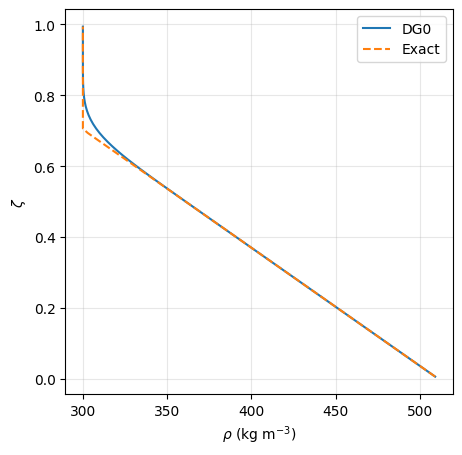

In [7]:
transport = run_transport_only(final_time=20.0)

print(
    f"Transport relative L2 error = "
    f"{transport['relative_L2_error']:.3e}"
)
print(
    f"Maximum mass-budget error   = "
    f"{np.max(np.abs(transport['budget_errors'])):.3e}"
)

zeta_centers = (
    np.arange(transport["n_cells"]) + 0.5
) / transport["n_cells"]

rho_num = sample_1d(transport["rho"], zeta_centers)

rho_exact_f = Function(transport["rho"].function_space())
rho_exact_f.interpolate(transport["rho_exact_expr"])
rho_exact = sample_1d(rho_exact_f, zeta_centers)

plt.figure(figsize=(5, 5))
plt.plot(rho_num, zeta_centers, label="DG0")
plt.plot(rho_exact, zeta_centers, "--", label="Exact")
plt.xlabel(r"$\rho$ (kg m$^{-3}$)")
plt.ylabel(r"$\zeta$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 4. Constant-state preservation

Set $C=0$, $a_s=a_b$, $p=-a_s$, and constant $\rho$. Any change indicates
a boundary-flux or sign error.

In [31]:
constant_state = run_transport_only(
    final_time=10.0,
    p_value=-a_s_value,
    density_contrast=0.0,
)

constant_state_error = np.max(
    np.abs(constant_state["rho"].dat.data_ro - rho_s_value)
)

print(f"Constant-state max error = {constant_state_error:.3e}")
print(
    f"Constant-state max budget error = "
    f"{np.max(np.abs(constant_state['budget_errors'])):.3e}"
)

assert constant_state_error < 1.0e-10

Constant-state max error = 0.000e+00
Constant-state max budget error = 0.000e+00


## 5. Thickness ODE

With prescribed column-mean fractional compaction $g$,

$$
\dot h=a_s-a_b-gh.
$$

The exact solution is
$h=h_\infty+(h_0-h_\infty)e^{-gt}$, where
$h_\infty=(a_s-a_b)/g$.

Final thickness error = 1.291e-03 m


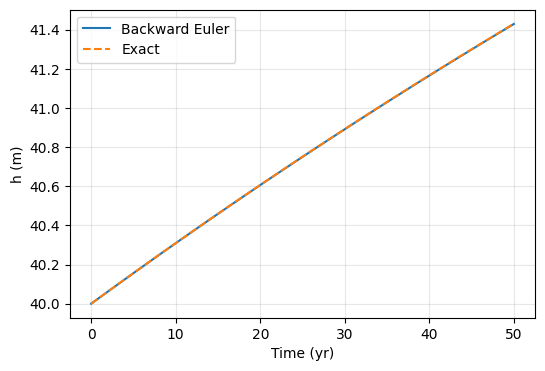

In [32]:
mesh_h = UnitIntervalMesh(1)
V_h_ode = FunctionSpace(mesh_h, "R", 0)

h_ode = Function(V_h_ode, name="h")
h_old_ode = Function(V_h_ode, name="h_old")
eta_ode = TestFunction(V_h_ode)

gbar_value = 0.004   # yr^-1
h0_value = 40.0      # m
dt_h_value = 0.5     # yr
final_time_h = 50.0  # yr

a_difference = a_s_value - a_b_target_value
h_equilibrium = a_difference / gbar_value

dt_h = Constant(dt_h_value)
gbar = Constant(gbar_value)

h_ode.assign(h0_value)
h_old_ode.assign(h_ode)

F_h_ode = (
    (h_ode - h_old_ode) / dt_h
    - a_difference
    + gbar * h_ode
) * eta_ode * dx

times_h = [0.0]
values_h = [float(h_ode)]

time_h = 0.0

while time_h < final_time_h - 1.0e-12:
    step_dt = min(dt_h_value, final_time_h - time_h)
    dt_h.assign(step_dt)

    solve(F_h_ode == 0, h_ode)

    time_h += step_dt
    times_h.append(time_h)
    values_h.append(float(h_ode))

    h_old_ode.assign(h_ode)

times_h = np.asarray(times_h)
values_h = np.asarray(values_h)

h_exact_values = (
    h_equilibrium
    + (h0_value - h_equilibrium)
    * np.exp(-gbar_value * times_h)
)

print(
    f"Final thickness error = "
    f"{abs(values_h[-1] - h_exact_values[-1]):.3e} m"
)

plt.figure(figsize=(6, 4))
plt.plot(times_h, values_h, label="Backward Euler")
plt.plot(times_h, h_exact_values, "--", label="Exact")
plt.xlabel("Time (yr)")
plt.ylabel("h (m)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 6. Full stationary coupled problem on the extruded column

Spaces:

- $\rho\in DG_0\times DG_0$;
- $h\in DG_0\times R$;
- $p\in DG_0\times CG_1$.

Only $p(1)=-a_s$ is imposed strongly. Density boundary fluxes use the solved
$p$, rather than separate prescribed surface and basal mass fluxes.

In [10]:
n_horizontal = 1
n_vertical = 80

base_mesh = UnitIntervalMesh(n_horizontal)
mesh = ExtrudedMesh(
    base_mesh,
    layers=n_vertical,
    layer_height=1.0 / n_vertical,
)

zeta_axis = mesh.geometric_dimension - 1
zeta = SpatialCoordinate(mesh)[zeta_axis]

V_rho = FunctionSpace(
    mesh,
    "DG", 0,
    vfamily="DG", vdegree=0,
)

V_h = FunctionSpace(
    mesh,
    "DG", 0,
    vfamily="R", vdegree=0,
)

V_p = FunctionSpace(
    mesh,
    "DG", 0,
    vfamily="CG", vdegree=1,
)

W = V_rho * V_h * V_p

state = Function(W, name="firn_state")
rho, h, p = split(state)
phi, eta, psi = TestFunctions(W)

rho_f, h_f, p_f = state.subfunctions

rho_i = Constant(rho_i_value)
rho_s = Constant(rho_s_value)
a_s = Constant(a_s_value)
a_b = Constant(a_b_target_value)
c = Constant(c_value)

rho_exact_expr = rho_hl_ufl(zeta, h_target_value)
p_exact_expr = -rho_s * a_s / rho_exact_expr

rho_f.interpolate(rho_exact_expr)
h_f.assign(h_target_value)
p_f.interpolate(p_exact_expr)

print("Degrees of freedom")
print(f"  rho: {V_rho.dim()}")
print(f"  h:   {V_h.dim()}")
print(f"  p:   {V_p.dim()}")
print(f"  all: {W.dim()}")

Degrees of freedom
  rho: 80
  h:   1
  p:   81
  all: 162


In [11]:
def vertical_density_advection_form(
    rho,
    p,
    phi,
    *,
    mesh,
    zeta_axis,
    rho_surface,
):
    """
    DG form for vertical div_zeta(rho*p).

    Top inflow uses rho_surface. The base always uses the interior trace.
    """
    normal = FacetNormal(mesh)

    P = as_vector(
        tuple([0.0] * (mesh.geometric_dimension - 1) + [p])
    )

    P_dot_n = dot(P, normal)
    outward_speed = 0.5 * (P_dot_n + abs(P_dot_n))

    flux_hat_nplus = (
        outward_speed("+") * rho("+")
        - outward_speed("-") * rho("-")
    )

    rho_top_upwind = conditional(
        p < 0.0,
        rho_surface,
        rho,
    )

    return (
        -rho * p * phi.dx(zeta_axis) * dx

        + (phi("+") - phi("-"))
          * flux_hat_nplus * dS_h

        # Top outward flux, n_zeta=+1.
        + rho_top_upwind * p * phi * ds_t

        # Basal outward flux, n_zeta=-1.
        - rho * p * phi * ds_b
    )


C = c * a_s * (rho_i - rho)
g = C / rho

F_rho_stationary = vertical_density_advection_form(
    rho,
    p,
    phi,
    mesh=mesh,
    zeta_axis=zeta_axis,
    rho_surface=rho_s,
)

F_h_stationary = (
    -a_s + a_b + h * g
) * eta * dx

F_p_stationary = (
    p.dx(zeta_axis) + h * g
) * psi * dx

F_stationary = (
    F_rho_stationary
    + F_h_stationary
    + F_p_stationary
)

bc_p_surface = DirichletBC(
    W.sub(2),
    -a_s,
    "top",
)

bcs = [bc_p_surface]

print(f"Constrained top-p dofs: {len(bc_p_surface.nodes)}")
assert len(bc_p_surface.nodes) > 0

Constrained top-p dofs: 1


In [12]:
# R-space couplings should remain in a nested matrix.
stationary_solver_parameters = {
    "mat_type": "nest",

    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_rtol": 1.0e-10,
    "snes_atol": 1.0e-11,
    "snes_max_it": 30,

    "ksp_type": "fgmres",
    "ksp_rtol": 1.0e-10,
    "ksp_atol": 1.0e-12,
    "ksp_max_it": 300,

    "pc_type": "fieldsplit",
    "pc_fieldsplit_type": "multiplicative",

    "fieldsplit_0_ksp_type": "preonly",
    "fieldsplit_0_pc_type": "lu",

    "fieldsplit_1_ksp_type": "preonly",
    "fieldsplit_1_pc_type": "lu",

    "fieldsplit_2_ksp_type": "gmres",
    "fieldsplit_2_ksp_rtol": 1.0e-10,
    "fieldsplit_2_ksp_atol": 1.0e-12,
    "fieldsplit_2_ksp_max_it": 200,
    "fieldsplit_2_ksp_gmres_restart": 100,
    "fieldsplit_2_pc_type": "none",
}

stationary_problem = NonlinearVariationalProblem(
    F_stationary,
    state,
    bcs=bcs,
)

stationary_solver = NonlinearVariationalSolver(
    stationary_problem,
    solver_parameters=stationary_solver_parameters,
)

stationary_solver.solve()

state_steady = Function(W, name="discrete_steady_state")
state_steady.assign(state)

print(
    f"Final stationary residual norm = "
    f"{stationary_solver.snes.getFunctionNorm():.3e}"
)

Final stationary residual norm = 4.095e-13


h                         = 13.73672670 m
|h-h_target|              = 2.540e-01 m
rho_b                     = 830.00000000 kg m^-3
p_s + a_s                 = 0.000e+00
p_b + a_b                 = -2.776e-17
relative L2 rho error      = 5.489e-03
relative L2 p error        = 3.837e-15
relative L2 flux variation = 8.333e-03


/opt/firedrake/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
/opt/firedrake/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
/opt/firedrake/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


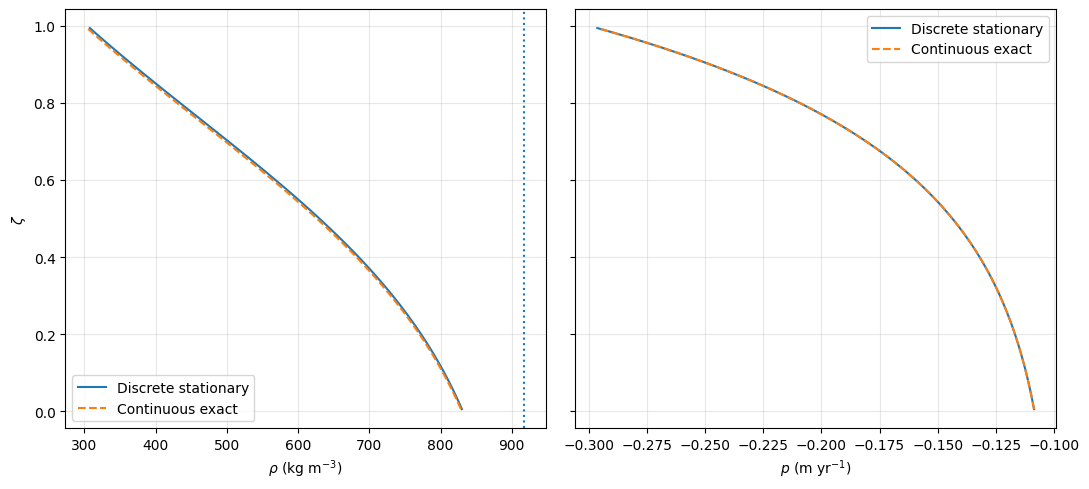

In [13]:
column_volume = assemble(Constant(1.0) * dx(domain=mesh))
top_area = assemble(Constant(1.0) * ds_t(domain=mesh))
bottom_area = assemble(Constant(1.0) * ds_b(domain=mesh))

h_num = assemble(h_f * dx) / column_volume
rho_b_num = assemble(rho_f * ds_b) / bottom_area
p_s_num = assemble(p_f * ds_t) / top_area
p_b_num = assemble(p_f * ds_b) / bottom_area

rho_target = Function(V_rho)
rho_target.interpolate(rho_exact_expr)

p_target = Function(V_p)
p_target.interpolate(p_exact_expr)

rho_relative_L2 = sqrt(
    assemble((rho_f - rho_target)**2 * dx(domain=mesh))
    / assemble(rho_target**2 * dx(domain=mesh))
)

p_relative_L2 = sqrt(
    assemble((p_f - p_target)**2 * dx(domain=mesh))
    / assemble(p_target**2 * dx(domain=mesh))
)

flux_relative_L2 = sqrt(
    assemble((rho_f * p_f + rho_s * a_s)**2 * dx(domain=mesh))
    / assemble((rho_s * a_s)**2 * dx(domain=mesh))
)

print(f"h                         = {h_num:.8f} m")
print(f"|h-h_target|              = {abs(h_num-h_target_value):.3e} m")
print(f"rho_b                     = {rho_b_num:.8f} kg m^-3")
print(f"p_s + a_s                 = {p_s_num+a_s_value:.3e}")
print(f"p_b + a_b                 = {p_b_num+a_b_target_value:.3e}")
print(f"relative L2 rho error      = {rho_relative_L2:.3e}")
print(f"relative L2 p error        = {p_relative_L2:.3e}")
print(f"relative L2 flux variation = {flux_relative_L2:.3e}")

zeta_plot = (np.arange(n_vertical) + 0.5) / n_vertical

rho_values = sample_extruded_column(rho_f, zeta_plot)
p_values = sample_extruded_column(p_f, zeta_plot)

rho_exact_values = rho_hl_numpy(zeta_plot)
p_exact_values = p_hl_numpy(zeta_plot)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

axes[0].plot(rho_values, zeta_plot, label="Discrete stationary")
axes[0].plot(rho_exact_values, zeta_plot, "--", label="Continuous exact")
axes[0].axvline(rho_i_value, linestyle=":")
axes[0].set_xlabel(r"$\rho$ (kg m$^{-3}$)")
axes[0].set_ylabel(r"$\zeta$")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(p_values, zeta_plot, label="Discrete stationary")
axes[1].plot(p_exact_values, zeta_plot, "--", label="Continuous exact")
axes[1].set_xlabel(r"$p$ (m yr$^{-1}$)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Spatial convergence of the stationary solution

Because \(\rho\) is \(DG_0\), first-order \(L^2\) convergence is the natural
expectation. Judge the method by a consistent refinement trend, not by one plot.

In [14]:
def solve_stationary_at_resolution(n_vertical):
    """Solve the full stationary column and return scalar errors."""
    base = UnitIntervalMesh(1)
    mesh_n = ExtrudedMesh(
        base,
        layers=n_vertical,
        layer_height=1.0 / n_vertical,
    )

    zaxis = mesh_n.geometric_dimension - 1
    zeta_n = SpatialCoordinate(mesh_n)[zaxis]

    Vr = FunctionSpace(
        mesh_n, "DG", 0,
        vfamily="DG", vdegree=0,
    )
    Vh = FunctionSpace(
        mesh_n, "DG", 0,
        vfamily="R", vdegree=0,
    )
    Vp = FunctionSpace(
        mesh_n, "DG", 0,
        vfamily="CG", vdegree=1,
    )
    Wn = Vr * Vh * Vp

    state_n = Function(Wn)
    rho_n, h_n, p_n = split(state_n)
    phi_n, eta_n, psi_n = TestFunctions(Wn)

    rho_nf, h_nf, p_nf = state_n.subfunctions

    rho_i_n = Constant(rho_i_value)
    rho_s_n = Constant(rho_s_value)
    a_s_n = Constant(a_s_value)
    a_b_n = Constant(a_b_target_value)
    c_n = Constant(c_value)

    rho_exact_n = rho_hl_ufl(zeta_n, h_target_value)
    p_exact_n = -rho_s_n * a_s_n / rho_exact_n

    rho_nf.interpolate(rho_exact_n)
    h_nf.assign(h_target_value)
    p_nf.interpolate(p_exact_n)

    C_n = c_n * a_s_n * (rho_i_n - rho_n)
    g_n = C_n / rho_n

    F_n = (
        vertical_density_advection_form(
            rho_n,
            p_n,
            phi_n,
            mesh=mesh_n,
            zeta_axis=zaxis,
            rho_surface=rho_s_n,
        )
        + (-a_s_n + a_b_n + h_n * g_n) * eta_n * dx
        + (p_n.dx(zaxis) + h_n * g_n) * psi_n * dx
    )

    bc_n = DirichletBC(Wn.sub(2), -a_s_n, "top")

    quiet_params = {
        key: value
        for key, value in stationary_solver_parameters.items()
        if key not in {"snes_converged_reason", "ksp_converged_reason"}
    }

    problem_n = NonlinearVariationalProblem(F_n, state_n, bcs=[bc_n])
    solver_n = NonlinearVariationalSolver(
        problem_n,
        solver_parameters=quiet_params,
    )
    solver_n.solve()

    rho_target_n = Function(Vr)
    rho_target_n.interpolate(rho_exact_n)

    p_target_n = Function(Vp)
    p_target_n.interpolate(p_exact_n)

    rho_error = float(sqrt(
        assemble((rho_nf - rho_target_n)**2 * dx)
        / assemble(rho_target_n**2 * dx)
    ))

    p_error = float(sqrt(
        assemble((p_nf - p_target_n)**2 * dx)
        / assemble(p_target_n**2 * dx)
    ))

    volume_n = assemble(Constant(1.0) * dx(domain=mesh_n))
    h_value_n = assemble(h_nf * dx) / volume_n

    return {
        "n": n_vertical,
        "rho_error": rho_error,
        "p_error": p_error,
        "h_error": abs(h_value_n - h_target_value),
    }


resolutions = [10, 20, 40, 80]
convergence = [solve_stationary_at_resolution(n) for n in resolutions]

print(" N    rho error      rate     p error        rate     h error")
print("-" * 70)

for i, row in enumerate(convergence):
    if i == 0:
        rho_rate = np.nan
        p_rate = np.nan
    else:
        previous = convergence[i - 1]
        rho_rate = np.log(
            previous["rho_error"] / row["rho_error"]
        ) / np.log(2.0)
        p_rate = np.log(
            previous["p_error"] / row["p_error"]
        ) / np.log(2.0)

    print(
        f"{row['n']:3d}  "
        f"{row['rho_error']:11.3e}  "
        f"{rho_rate:7.3f}  "
        f"{row['p_error']:11.3e}  "
        f"{p_rate:7.3f}  "
        f"{row['h_error']:11.3e}"
    )

 N    rho error      rate     p error        rate     h error
----------------------------------------------------------------------
 10    4.342e-02      nan    1.376e-13      nan    2.221e+00
 20    2.185e-02    0.991    4.378e-13   -1.670    1.055e+00
 40    1.096e-02    0.995    3.504e-14    3.643    5.143e-01
 80    5.489e-03    0.998    3.837e-15    3.191    2.540e-01


## 8. Literal Backward-Euler step from the discrete steady state

Before Irksome, write one Backward-Euler step directly. Starting from the discrete
stationary solution, all three fields should remain unchanged.

In [15]:
state_old_be = Function(W)
state_old_be.assign(state_steady)

state_new_be = Function(W)
state_new_be.assign(state_steady)

rho_old_be, h_old_be, _ = split(state_old_be)
rho_new_be, h_new_be, p_new_be = split(state_new_be)
phi_be, eta_be, psi_be = TestFunctions(W)

dt_be = Constant(0.05)

C_new_be = c * a_s * (rho_i - rho_new_be)
g_new_be = C_new_be / rho_new_be

F_be = (
    (h_new_be * rho_new_be - h_old_be * rho_old_be)
    / dt_be * phi_be * dx

    + vertical_density_advection_form(
        rho_new_be,
        p_new_be,
        phi_be,
        mesh=mesh,
        zeta_axis=zeta_axis,
        rho_surface=rho_s,
    )

    + (
        (h_new_be - h_old_be) / dt_be
        - a_s + a_b
        + h_new_be * g_new_be
    ) * eta_be * dx

    + (
        (h_new_be - h_old_be) / dt_be
        + p_new_be.dx(zeta_axis)
        + h_new_be * g_new_be
    ) * psi_be * dx
)

bc_be = DirichletBC(W.sub(2), -a_s, "top")

problem_be = NonlinearVariationalProblem(
    F_be,
    state_new_be,
    bcs=[bc_be],
)

solver_be = NonlinearVariationalSolver(
    problem_be,
    solver_parameters=stationary_solver_parameters,
)

solver_be.solve()

rho_old_f, h_old_f, p_old_f = state_old_be.subfunctions
rho_new_f, h_new_f, p_new_f = state_new_be.subfunctions

rho_change = sqrt(assemble((rho_new_f - rho_old_f)**2 * dx))
p_change = sqrt(assemble((p_new_f - p_old_f)**2 * dx))

h_old_value = assemble(h_old_f * dx) / column_volume
h_new_value = assemble(h_new_f * dx) / column_volume
h_change = abs(h_new_value - h_old_value)

print(f"One-step rho change = {rho_change:.3e}")
print(f"One-step h change   = {h_change:.3e}")
print(f"One-step p change   = {p_change:.3e}")

One-step rho change = 0.000e+00
One-step h change   = 0.000e+00
One-step p change   = 0.000e+00


## 9. One Irksome Backward-Euler step

This checks the semi-discrete `Dt(...)` formulation against the explicit
Backward-Euler benchmark for the differential–algebraic system.

In [37]:
def build_semidiscrete_form(state):
    """Construct the coupled semi-discrete residual used by Irksome."""
    rho, h, p = split(state)
    phi, eta, psi = TestFunctions(state.function_space())

    C = c * a_s * (rho_i - rho)
    g = C / rho

    F_rho = (
        Dt(h * rho) * phi * dx
        + vertical_density_advection_form(
            rho,
            p,
            phi,
            mesh=mesh,
            zeta_axis=zeta_axis,
            rho_surface=rho_s,
        )
    )

    # Keep the Dt term in a separate integral.
    F_h = (
        Dt(h) * eta * dx
        + (-a_s + a_b + h * g) * eta * dx
    )

    # Likewise here.
    F_p = (
        Dt(h) * psi * dx
        + (p.dx(zeta_axis) + h * g) * psi * dx
    )

    return F_rho + F_h + F_p


state_irk_steady = Function(W)
state_irk_steady.assign(state_steady)

state_before_irk = Function(W)
state_before_irk.assign(state_irk_steady)

F_irk_steady = build_semidiscrete_form(state_irk_steady)

MC = MeshConstant(mesh)
time_irk = MC.Constant(0.0)
dt_irk = MC.Constant(0.05)

bc_irk = DirichletBC(W.sub(2), -a_s, "top")

stepper_steady = TimeStepper(
    F_irk_steady,
    BackwardEuler(),
    time_irk,
    dt_irk,
    state_irk_steady,
    bcs=[bc_irk],
    stage_type="value",
    solver_parameters=stationary_solver_parameters,
)

stepper_steady.advance()
time_irk.assign(float(time_irk) + float(dt_irk))

rho_before, h_before, p_before = state_before_irk.subfunctions
rho_after, h_after, p_after = state_irk_steady.subfunctions

rho_change_irk = sqrt(assemble((rho_after - rho_before)**2 * dx))
p_change_irk = sqrt(assemble((p_after - p_before)**2 * dx))

h_before_value = assemble(h_before * dx) / column_volume
h_after_value = assemble(h_after * dx) / column_volume
h_change_irk = abs(h_after_value - h_before_value)

print(f"Irksome rho change = {rho_change_irk:.3e}")
print(f"Irksome h change   = {h_change_irk:.3e}")
print(f"Irksome p change   = {p_change_irk:.3e}")

Irksome rho change = 0.000e+00
Irksome h change   = 0.000e+00
Irksome p change   = 0.000e+00


## 10. Perturbed transient relaxation

Perturb the discrete steady density while preserving the surface value. Before
time stepping, recompute a consistent diagnostic $p$:

1. compute $\dot h$ from the thickness equation;
2. solve
   $$
   p_\zeta+\dot h+hC/\rho=0,\qquad p(1)=-a_s.
   $$

In [38]:
def make_p_consistent(state):
    """
    Recompute p from

        p_zeta + h_t + h*C/rho = 0,
        p(1) = -a_s.

    rho and h are held fixed.
    """
    rho_f, h_f, p_f = state.subfunctions

    C_f = c * a_s * (rho_i - rho_f)
    g_f = C_f / rho_f

    volume = assemble(Constant(1.0) * dx(domain=mesh))

    h_value = assemble(h_f * dx) / volume
    gbar_value = assemble(g_f * dx) / volume

    hdot_value = (
        a_s_value
        - a_b_target_value
        - h_value * gbar_value
    )

    # Use the original standalone V_p, not p_f.function_space(),
    # which is an indexed subspace of W.
    p_tmp = Function(V_p, name="p_consistent")
    p_tmp.assign(p_f)

    p_trial = TrialFunction(V_p)
    psi_p = TestFunction(V_p)

    a_p = p_trial.dx(zeta_axis) * psi_p * dx

    L_p = -(
        Constant(hdot_value)
        + h_f * g_f
    ) * psi_p * dx

    bc_p = DirichletBC(
        V_p,
        -a_s_value,
        "top",
    )

    solve(
        a_p == L_p,
        p_tmp,
        bcs=bc_p,
        solver_parameters={
            "ksp_type": "gmres",
            "ksp_rtol": 1.0e-12,
            "ksp_atol": 1.0e-14,
            "ksp_max_it": 300,
            "ksp_gmres_restart": 100,
        },
    )

    # Copy the standalone solution back into the mixed state.
    p_f.assign(p_tmp)

    return hdot_value

state_transient = Function(W)
state_transient.assign(state_steady)

rho_transient_f, h_transient_f, p_transient_f = (
    state_transient.subfunctions
)

# The perturbation vanishes at both boundaries.
rho_transient_f.interpolate(
    rho_exact_expr * (1.0 + 0.1 * sin(pi * zeta))
)

h_transient_f.assign(h_target_value)

initial_hdot = make_p_consistent(state_transient)

state_initial_perturbed = Function(W)
state_initial_perturbed.assign(state_transient)

print(f"Consistent initial h_t = {initial_hdot:.6e} m yr^-1")

Consistent initial h_t = 2.713361e-02 m yr^-1


In [48]:
F_transient = build_semidiscrete_form(state_transient)

time = MC.Constant(0.0)
dt = MC.Constant(50.0)

bc_transient = DirichletBC(
    W.sub(2),
    -a_s,
    "top",
)

stepper = TimeStepper(
    F_transient,
    BackwardEuler(),
    time,
    dt,
    state_transient,
    bcs=[bc_transient],
    stage_type="value",
    solver_parameters=stationary_solver_parameters,
)

final_time = 10000.0
print_every = 100

history = {
    "time": [],
    "h": [],
    "rho_min": [],
    "rho_max": [],
    "p_base_compatibility": [],
    "mass_budget_error": [],
    "p_residual": [],
    "h_residual": [],
}

rho_now, h_now, p_now = state_transient.subfunctions

M_old = assemble(h_now * rho_now * dx)
h_old_value = assemble(h_now * dx) / column_volume

step = 0

while float(time) < final_time - 1.0e-12:
    remaining = final_time - float(time)
    if remaining < float(dt):
        dt.assign(remaining)

    dt_now = float(dt)

    stepper.advance()
    time.assign(float(time) + dt_now)
    step += 1

    rho_now, h_now, p_now = state_transient.subfunctions

    M_new = assemble(h_now * rho_now * dx)
    h_now_value = assemble(h_now * dx) / column_volume
    hdot_num = (h_now_value - h_old_value) / dt_now

    # Actual p-based boundary mass fluxes.
    top_outward = assemble(rho_s * p_now * ds_t)
    basal_outward = assemble(-rho_now * p_now * ds_b)

    numerical_Mdot = (M_new - M_old) / dt_now
    expected_Mdot = -(top_outward + basal_outward)
    mass_budget_error = numerical_Mdot - expected_Mdot

    p_surface = assemble(p_now * ds_t) / top_area
    p_base = assemble(p_now * ds_b) / bottom_area

    C_now = c * a_s * (rho_i - rho_now)
    g_now = C_now / rho_now
    gbar_now = assemble(g_now * dx) / column_volume

    p_residual = sqrt(assemble(
        (
            Constant(hdot_num)
            + p_now.dx(zeta_axis)
            + h_now * g_now
        )**2 * dx
    ))

    h_residual = (
        hdot_num
        - a_s_value
        + a_b_target_value
        + h_now_value * gbar_now
    )

    history["time"].append(float(time))
    history["h"].append(h_now_value)
    history["rho_min"].append(rho_now.dat.data_ro.min())
    history["rho_max"].append(rho_now.dat.data_ro.max())
    history["p_base_compatibility"].append(
        p_base + a_b_target_value
    )
    history["mass_budget_error"].append(mass_budget_error)
    history["p_residual"].append(float(p_residual))
    history["h_residual"].append(h_residual)

    if step % print_every == 0 or float(time) >= final_time - 1.0e-12:
        print(
            f"t={float(time):6.2f} yr | "
            f"h={h_now_value:9.4f} m | "
            f"rho=[{rho_now.dat.data_ro.min():7.2f}, "
            f"{rho_now.dat.data_ro.max():7.2f}] | "
            f"p_s+a_s={p_surface+a_s_value:9.2e} | "
            f"p_b+a_b={p_base+a_b_target_value:9.2e} | "
            f"mass err={mass_budget_error:9.2e} | "
            f"p res={float(p_residual):9.2e}"
        )

    M_old = M_new
    h_old_value = h_now_value

for key in history:
    history[key] = np.asarray(history[key])

t=5000.00 yr | h=  13.7367 m | rho=[ 307.56,  830.00] | p_s+a_s= 0.00e+00 | p_b+a_b=-2.78e-17 | mass err=-4.95e-14 | p res= 4.20e-15
t=10000.00 yr | h=  13.7367 m | rho=[ 307.56,  830.00] | p_s+a_s= 0.00e+00 | p_b+a_b=-2.78e-17 | mass err= 9.72e-14 | p res= 1.13e-15


/opt/firedrake/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


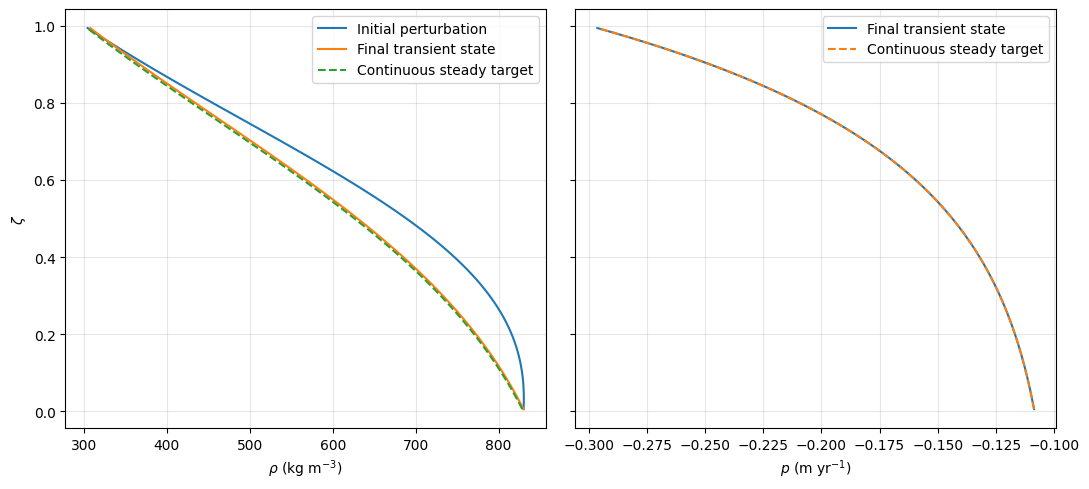

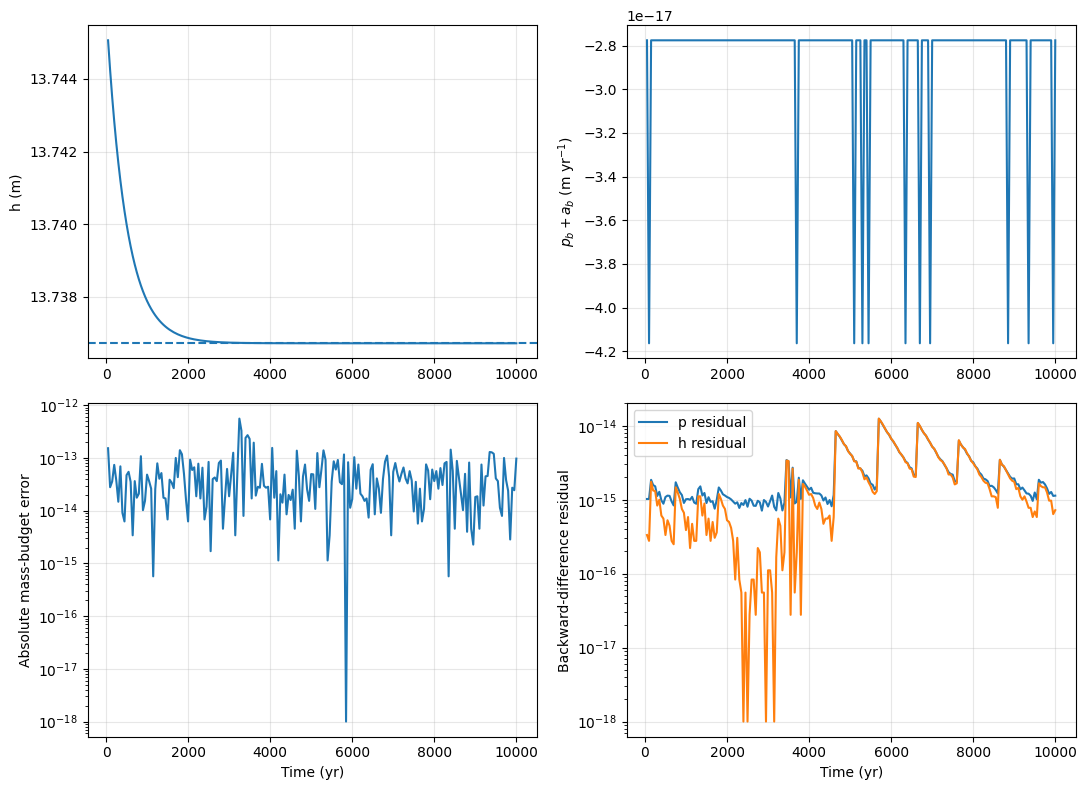

Maximum absolute mass-budget error = 5.576e-13
Maximum absolute p_b+a_b           = 4.163e-17
Final density range                = [307.558, 830.000]


In [49]:
rho_initial_perturbed, _, _ = state_initial_perturbed.subfunctions
rho_final, h_final, p_final = state_transient.subfunctions

rho_initial_values = sample_extruded_column(
    rho_initial_perturbed,
    zeta_plot,
)

rho_final_values = sample_extruded_column(
    rho_final,
    zeta_plot,
)

p_final_values = sample_extruded_column(
    p_final,
    zeta_plot,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

axes[0].plot(
    rho_initial_values,
    zeta_plot,
    label="Initial perturbation",
)
axes[0].plot(
    rho_final_values,
    zeta_plot,
    label="Final transient state",
)
axes[0].plot(
    rho_exact_values,
    zeta_plot,
    "--",
    label="Continuous steady target",
)
axes[0].set_xlabel(r"$\rho$ (kg m$^{-3}$)")
axes[0].set_ylabel(r"$\zeta$")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    p_final_values,
    zeta_plot,
    label="Final transient state",
)
axes[1].plot(
    p_exact_values,
    zeta_plot,
    "--",
    label="Continuous steady target",
)
axes[1].set_xlabel(r"$p$ (m yr$^{-1}$)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

_, h_ss, _ = state_steady.subfunctions
h_ss_value = assemble(h_ss * dx) / column_volume
axes[0, 0].plot(history["time"], history["h"])
axes[0, 0].axhline(h_ss_value, linestyle="--")
axes[0, 0].set_ylabel("h (m)")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(
    history["time"],
    history["p_base_compatibility"],
)
axes[0, 1].set_ylabel(r"$p_b+a_b$ (m yr$^{-1}$)")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].semilogy(
    history["time"],
    np.maximum(
        np.abs(history["mass_budget_error"]),
        1.0e-18,
    ),
)
axes[1, 0].set_xlabel("Time (yr)")
axes[1, 0].set_ylabel("Absolute mass-budget error")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].semilogy(
    history["time"],
    np.maximum(np.abs(history["p_residual"]), 1.0e-18),
    label="p residual",
)
axes[1, 1].semilogy(
    history["time"],
    np.maximum(np.abs(history["h_residual"]), 1.0e-18),
    label="h residual",
)
axes[1, 1].set_xlabel("Time (yr)")
axes[1, 1].set_ylabel("Backward-difference residual")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(
    f"Maximum absolute mass-budget error = "
    f"{np.max(np.abs(history['mass_budget_error'])):.3e}"
)
print(
    f"Maximum absolute p_b+a_b           = "
    f"{np.max(np.abs(history['p_base_compatibility'])):.3e}"
)
print(
    f"Final density range                = "
    f"[{history['rho_min'][-1]:.3f}, "
    f"{history['rho_max'][-1]:.3f}]"
)

## Interpretation checklist

Do not add horizontal transport until all of these pass:

1. Both isolated \(p\)-solves reproduce the linear exact solution.
2. The DG transport test moves the profile downward and closes its mass budget.
3. The constant state is preserved.
4. The thickness ODE follows its analytical solution.
5. The stationary coupled solution converges toward the corrected HL profile under
   refinement.
6. Literal Backward Euler preserves the discrete stationary state.
7. Irksome preserves the same state to comparable tolerance.
8. During perturbed relaxation:
   - \(p_s+a_s\approx0\);
   - \(p_b+a_b\approx0\);
   - the mass budget is computed from actual \(p\);
   - density remains positive and below ice density;
   - no basal sign reversal is hidden by a prescribed sink.

In [41]:
# Compare discrete steady-state thickness with the final transient thickness

_, h_ss, _ = state_steady.subfunctions
_, h_tr, _ = state_transient.subfunctions

column_volume = assemble(Constant(1.0) * dx(domain=mesh))

h_ss_value = assemble(h_ss * dx) / column_volume
h_tr_value = assemble(h_tr * dx) / column_volume

print(f"Discrete steady-state h = {h_ss_value:.12f} m")
print(f"Final transient h       = {h_tr_value:.12f} m")
print(f"Difference              = {h_tr_value - h_ss_value:+.12e} m")

Discrete steady-state h = 13.736726702024 m
Final transient h       = 13.817937476302 m
Difference              = +8.121077427793e-02 m


In [42]:
def report_h_balance(label, state):
    rho_f, h_f, _ = state.subfunctions

    volume = assemble(Constant(1.0) * dx(domain=mesh))
    h_value = assemble(h_f * dx) / volume

    C_f = c * a_s * (rho_i - rho_f)
    g_f = C_f / rho_f
    gbar = assemble(g_f * dx) / volume

    hdot_required = (
        a_s_value
        - a_b_target_value
        - h_value * gbar
    )

    print(label)
    print(f"  h                       = {h_value:.12f}")
    print(f"  mean(C/rho)             = {gbar:.12e}")
    print(f"  required h_t            = {hdot_required:+.12e}")
    print(f"  static thickness resid. = {-hdot_required:+.12e}")


report_h_balance("Stationary solve", state_steady)
report_h_balance("Final transient", state_transient)

Stationary solve
  h                       = 13.736726702024
  mean(C/rho)             = 1.394555407672e-02
  required h_t            = -8.937295348233e-15
  static thickness resid. = +8.937295348233e-15
Final transient
  h                       = 13.817937476302
  mean(C/rho)             = 1.387631548871e-02
  required h_t            = -1.757947641300e-04
  static thickness resid. = +1.757947641300e-04


In [35]:
state.assign(state_transient)
stationary_solver.solve()

_, h_recomputed, _ = state.subfunctions
h_recomputed_value = assemble(h_recomputed * dx) / column_volume

print(f"Stationary solve initialized from transient: {h_recomputed_value:.12f} m")

Stationary solve initialized from transient: 13.736726702023 m
